Stochastic Variational Bayes - example nonlinear model
==============================================

This notebook implements stochastic variational Bayes for a nonlinear model. The model we will use is a bi-exponential model, i.e. we will assume our data reflects a time-dependent signal of the following form:

$$S_{true}(t) = A_1 e^{-R_1t} + A_2 e^{-R_2t}$$

However the actual time dependent signal $S(t)$ will be affected by additive Gaussian noise, so will have the distribution:

$$P(S(t)) = \frac{\sqrt{\beta}}{\sqrt{2\pi}} \exp{\bigg(-\frac{\beta}{2} (S(t) - S_{true}(t))^2}\bigg)$$

Given $S(t)$ our aim will be to infer the values of $A_1$, $A_2$, $R_1$, $R_2$ and $\beta$.

Here's how we can generate some sample data from this model in Python:

In [1]:
import numpy as np
from tqdm.notebook import tqdm_notebook
from matplotlib import pyplot as plt
import torch

%matplotlib inline
# Ground truth parameters
# We infer the precision, BETA, but it is useful to
# derive the variance and standard deviation from it
A1_TRUTH = 10.0
A2_TRUTH = 10.0
R1_TRUTH = 10.0
R2_TRUTH = 1.0
BETA_TRUTH = 1.0
VAR_TRUTH = 1/BETA_TRUTH
STD_TRUTH = np.sqrt(VAR_TRUTH)

# Observed data samples are generated by Numpy from the ground truth
# Gaussian distribution. Reducing the number of samples should make
# the inference less 'confident' - i.e. the output variances for
# MU and BETA will increase
N = 200
T = np.linspace(0, 5, N)


DATA_CLEAN = A1_TRUTH * np.exp(-R1_TRUTH * T) + A2_TRUTH * np.exp(-R2_TRUTH*T)
DATA = DATA_CLEAN + np.random.normal(0, STD_TRUTH, [N])
print("Data samples are:")
print(DATA)

Data samples are:
[ 2.03541828e+01  1.79332794e+01  1.33908238e+01  1.22420781e+01
  1.49246477e+01  9.43103875e+00  1.09627166e+01  1.04310695e+01
  1.03980040e+01  8.19230680e+00  9.26172986e+00  8.28379712e+00
  7.02098326e+00  6.39027607e+00  8.00539813e+00  7.05347359e+00
  6.70182625e+00  5.98658632e+00  6.59333961e+00  7.02090904e+00
  5.26368692e+00  6.73704291e+00  5.61745404e+00  6.17539367e+00
  6.15070422e+00  4.67597602e+00  4.52459530e+00  5.89131246e+00
  4.73324544e+00  4.60753429e+00  4.69448072e+00  3.40926205e+00
  5.52435301e+00  3.87779642e+00  3.68859729e+00  4.32930668e+00
  4.13175022e+00  4.61071516e+00  4.20044361e+00  2.88588339e+00
  3.76318392e+00  5.66044830e+00  4.15660790e+00  5.76953296e+00
  4.29448420e+00  4.53697333e+00  2.40328921e+00  2.91922118e+00
  2.65968807e+00  2.84140438e+00  2.26873383e+00  2.45030752e+00
  3.06677072e+00  2.54585526e+00  2.23496105e+00  1.76587666e+00
  2.14550989e+00  2.51443883e+00  3.45320964e+00  7.57747699e-01
  2.662

We can plot this data to illustrate the true signal (green line) and the measured data (red crosses):

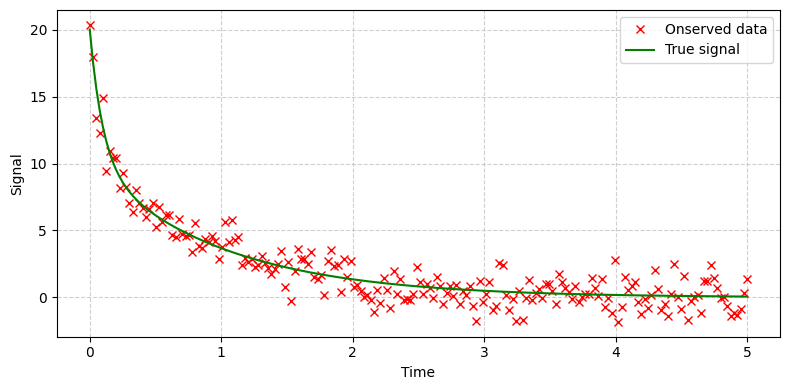

In [2]:
plt.figure(figsize=(8,4))
plt.xlabel("Time")
plt.ylabel("Signal")
plt.plot(T, DATA, "rx", label="Observed data")
plt.plot(T, DATA_CLEAN, "g", label="True signal")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

As with the single Gaussian example we will use a multivariate normal distribution as our prior and approximate posterior distributions. 

One difference here is that we will choose to infer the log of the decay rate parameters $R_1$ and $R_2$. This is because if these parameters are allowed to become negative the model prediction will become an exponential growth and can easily lead to numerical errors.

We will still choose our priors to be relatively uninformative as follows:


In [3]:
a0 = 1.0
v0 = 100000.0
r0 = 0.0
u0 = 10.0
b0 = 0.0
w0 = 10.0
print("Priors: Amplitude mean=%.2f, variance=%.2f" % (a0, v0))
print("        Log decay rate mean=%.2f, variance=%.2f" % (r0, u0))
print("        Log noise variance mean=%.2f, variance=%.2f" % (b0, w0))

Priors: Amplitude mean=1.00, variance=100000.00
        Log decay rate mean=0.00, variance=10.00
        Log noise variance mean=0.00, variance=10.00


The posterior will be defined in the same way as for the single Gaussian example, however we need to account for the increased number of parameters we are inferring. We will initialize the posterior with the prior values but with reduced initial variance to prevent problems with generating a representative posterior sample. Remember that the decay rates (and the noise) are being inferred as their log-values so the prior mean of 0 translates into a value of 1.

The code to generate a posterior sample is unchanged except for the number of parameters.

In calculating the reconstruction cost we need to calculate the log likelihood of the data given a set of model parameters. We do this by observing that any difference between the biexponential model prediction (given these parameters) and the actual noisy data must be a result of the Gaussian noise - hence the likelihood is simply the likelihood of drawing these differences from the Gaussian noise distribution:

$$\log P(\textbf{y} | A_1; A_2; r_1; r_2; \beta) = \frac{1}{2} \bigg( N \log \beta - \sum{\frac{(y_n - M_n)^2}{\beta}}\bigg)$$

Here $M_n$ is the model prediction for the nth data point which is calculated by evaluating the biexponential model for the given parameters $A_1$, $A_2$, $r_1$ and $r_2$.

For the latent loss we will again use the analytic expression for the K-L divergence of two MVN distributions with a slight modification to the previous code to account for the different number of parameters (5 vs 2)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

# Number of parameters - 4 for the biexponential + noise
NUM_PARAMS = 4 + 1

data = torch.tensor(DATA, dtype=dtype, device=device)  # shape [N]
prior_means = torch.tensor([a0, r0, a0, r0, b0], dtype=dtype, device=device)  # shape [NUM_PARAMS]
prior_covariance = torch.diag(torch.tensor([v0, u0, v0, u0, w0], dtype=dtype, device=device))  # [P,P]

post_means_init = prior_means.clone()
post_covariance_init = np.identity(NUM_PARAMS, dtype=np.float32)  # [P,P]

# Trainable variational parameters
chol_off_diag = torch.nn.Parameter(
    torch.zeros_like(torch.tensor(post_covariance_init, dtype=dtype, device=device))
)

chol_log_diag = torch.nn.Parameter(
    torch.log(torch.diag(torch.tensor(post_covariance_init, dtype=dtype, device=device)))
)  # [P]

post_means = torch.nn.Parameter(post_means_init)  # [P]

t = torch.tensor(T, dtype=dtype, device=device).reshape(1, -1)  # [1, N]

def cost_fun():
    # Build Cholesky factor for posterior covariance
    # chol_diag = diag(sqrt(exp(chol_log_diag)))
    chol_diag = torch.diag(torch.sqrt(torch.exp(chol_log_diag)))  # [P,P]

    # lower triangle (including diag) of chol_off_diag
    tril_off = torch.tril(chol_off_diag)  # [P,P]

    # L = chol_diag + tril_off
    post_covariance_chol = chol_diag + tril_off  # [P,P]

    post_covariance = post_covariance_chol.T @ post_covariance_chol  # [P,P]

    S = 5
    N = 200

    # eps ~ N(0, I) 
    eps = torch.randn((NUM_PARAMS, S), dtype=dtype, device=device)

    samples = post_means.view(NUM_PARAMS, 1).expand(NUM_PARAMS, S)

    # post_samples = samples + L @ eps
    post_samples = samples + (post_covariance_chol @ eps)  # [P,S]

    a1 = post_samples[0].reshape(-1, 1)                    # [S,1]
    r1 = torch.exp(post_samples[1].reshape(-1, 1))         # [S,1]
    a2 = post_samples[2].reshape(-1, 1)                    # [S,1]
    r2 = torch.exp(post_samples[3].reshape(-1, 1))         # [S,1]

    log_noise_var = -post_samples[4]                       # [S]
    noise_var = torch.exp(log_noise_var)                   # [S]

    prediction = a1 * torch.exp(-r1 * t) + a2 * torch.exp(-r2 * t)  # [S,N]

    diff = data.view(1, -1) - prediction                   # [S,N]

    sum_square_diff = torch.sum(diff * diff, dim=1)

    log_likelihood = 0.5 * (
        -log_noise_var * torch.tensor(float(N), device=device, dtype=dtype)
        - (sum_square_diff / noise_var)
    )

    reconstr_loss = -torch.mean(log_likelihood)

    # KL term (latent_loss)
    C = post_covariance
    C0 = prior_covariance
    C0_inv = torch.linalg.inv(C0)

    m_minus_m0 = (post_means - prior_means).reshape(-1, 1)  # [P,1]
    m_minus_m0_T = (post_means - prior_means).reshape(1, -1)  # [1,P]

    term1 = torch.trace(C0_inv @ C)

    
    signC, logdetC = torch.linalg.slogdet(C)
    signC0, logdetC0 = torch.linalg.slogdet(C0)
    term2 = -(logdetC - logdetC0)

    term3 = -NUM_PARAMS
    term4 = (m_minus_m0_T @ C0_inv @ m_minus_m0).squeeze()  # scalar

    latent_loss = 0.5 * (term1 + term2 + term3 + term4)

    cost = reconstr_loss


    return cost

Finally we ask PyTorch to minimise the total cost iteratively:

In [5]:
optimizer = torch.optim.Adam([post_means, chol_log_diag, chol_off_diag], lr=1e-2)

cost_history = []
for epoch in tqdm_notebook(range(5000), desc="Epoch:"):
    optimizer.zero_grad()
    loss = cost_fun()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(epoch, float(loss.detach().cpu()))
    cost_history.append(loss.detach().cpu().numpy())

Epoch::   0%|          | 0/5000 [00:00<?, ?it/s]

0 1958.7998046875
100 550.783935546875
200 355.6481628417969
300 302.02899169921875
400 254.9713897705078
500 241.78579711914062
600 245.5578155517578
700 216.34158325195312
800 219.5623321533203
900 202.6259765625
1000 190.85107421875
1100 184.48377990722656
1200 181.84814453125
1300 165.73924255371094
1400 159.4119415283203
1500 153.8290557861328
1600 145.56613159179688
1700 145.75045776367188
1800 138.54391479492188
1900 133.4035186767578
2000 130.4486541748047
2100 126.56181335449219
2200 124.72306060791016
2300 120.22723388671875
2400 115.2916030883789
2500 113.3272933959961
2600 111.25042724609375
2700 108.70933532714844
2800 107.33287048339844
2900 106.0238265991211
3000 105.1088638305664
3100 104.40340423583984
3200 103.94715881347656
3300 103.64961242675781
3400 103.43949890136719
3500 103.28962707519531
3600 103.22064208984375
3700 103.1601791381836
3800 103.2423095703125
3900 103.12701416015625
4000 103.10856628417969
4100 103.10462951660156
4200 103.09919738769531
4300 103.

In [6]:
final_means = post_means

# chol_diag = diag(sqrt(exp(chol_log_diag)))
chol_diag = torch.diag(torch.sqrt(torch.exp(chol_log_diag)))
post_covariance_chol = chol_diag + torch.tril(chol_off_diag)

# post_covariance = L^T L
post_covariance = post_covariance_chol.T @ post_covariance_chol

final_covariance = post_covariance

m = final_means.detach().cpu()
C = final_covariance.detach().cpu()

print("Estimate for amp1: %.5f (variance: %.5f)" % (m[0].item(), C[0, 0].item()))
print("Estimate for amp2: %.6f (variance: %.6f)" % (m[2].item(), C[2, 2].item()))
print("Estimate for r1: %.5f" % (torch.exp(m[1]).item(),))
print("Estimate for r2: %.5f" % (torch.exp(m[3]).item(),))
print("Estimate for beta (noise): %.5f" % (torch.exp(-m[4]).item(),))

Estimate for amp1: 10.71834 (variance: 0.00004)
Estimate for amp2: 9.471909 (variance: 0.000001)
Estimate for r1: 1.06730
Estimate for r2: 13.32816
Estimate for beta (noise): 1.03145


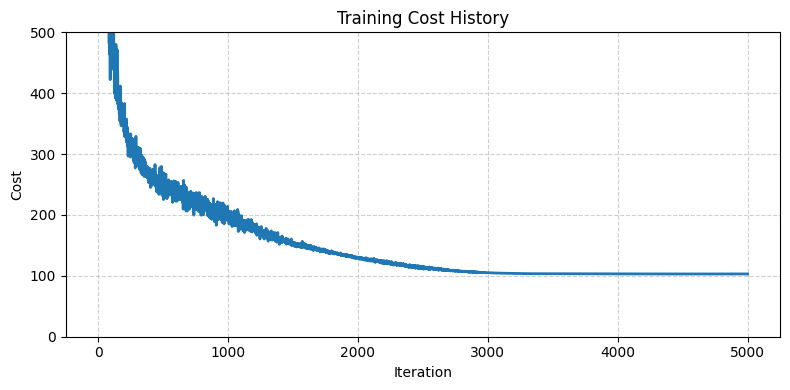

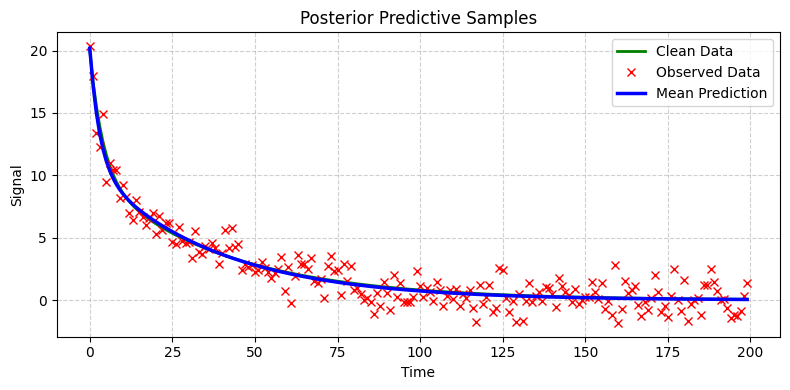

In [7]:
import matplotlib.pyplot as plt
import numpy as np


# Cost history plot
plt.figure(figsize=(8, 4))
plt.plot(cost_history, linewidth=2)
plt.ylim(0, 500)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Training Cost History")

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()



# Data visualization
plt.figure(figsize=(8, 4))

plt.plot(DATA_CLEAN, color='green', linewidth=2, label="Clean Data")
plt.plot(DATA, 'rx', label="Observed Data")

plt.xlabel("Time Index")
plt.ylabel("Signal Value")
plt.title("Observed vs Clean Data")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


# Posterior sampling
S = 5

eps = torch.randn((NUM_PARAMS, S), dtype=post_means.dtype, device=post_means.device)

samples = post_means.view(NUM_PARAMS, 1).expand(NUM_PARAMS, S)
post_samples = samples + (post_covariance_chol @ eps)

a1 = post_samples[0].reshape(-1, 1)
r1 = torch.exp(post_samples[1].reshape(-1, 1))
a2 = post_samples[2].reshape(-1, 1)
r2 = torch.exp(post_samples[3].reshape(-1, 1))

log_noise_var = -post_samples[4]
noise_var = torch.exp(log_noise_var)

t = torch.tensor(T, dtype=post_means.dtype, device=post_means.device).reshape(1, -1)

prediction = a1 * torch.exp(-r1 * t) + a2 * torch.exp(-r2 * t)

pred_np = prediction.detach().cpu().numpy()
# Plot posterior mean prediction
mean_pred = pred_np.mean(axis=0)
plt.plot(mean_pred, color='blue', linewidth=2.5, label="Mean Prediction")

plt.xlabel("Time")
plt.ylabel("Signal")
plt.title("Posterior Predictive Samples")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()